In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import os
import pickle

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

from collections import Counter
from upsetplot import UpSet
from scipy import stats
import gseapy as gp
from gseapy import barplot, dotplot

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

import time as time

from itertools import combinations
from itertools import product

In [2]:
plots_dir = "intersection_plots/"
os.makedirs(plots_dir, exist_ok=True)

In [8]:
def get_significant_genes(df, padj_threshold=0.05, lfc_threshold=0.5):
    sig = df[(df['padj'] < padj_threshold) & (df['log2FoldChange'].abs() > lfc_threshold)]
    
    up_genes = sig[sig['log2FoldChange'] > 0].index
    down_genes = sig[sig['log2FoldChange'] < 0].index
    
    return up_genes, down_genes

In [20]:
def load_DEG_df(contrast, cell_type):
    '''Load in the DEG for the specified contrast'''

    if contrast == "DCM":
        df = ( pd.read_csv("../non_binarized/pydeseq2_results/" + cell_type + "_disease_DCM_vs_ND_results.csv", 
                           index_col = 0) )
    elif contrast == "development":
        df = ( pd.read_csv("../../developmental_DEG_analysis/pydeseq2_results/" + cell_type + "_age_group_fetal_vs_young_results.csv", 
                               index_col = 0) )
    elif contrast == "ICM":
        df = ( pd.read_csv("../non_binarized/pydeseq2_results/" + cell_type + "_disease_ICM_vs_ND_results.csv", 
                               index_col = 0) )
    elif contrast == "HCM": 
        df = ( pd.read_csv("../non_binarized/pydeseq2_results/" + cell_type + "_disease_HCM_vs_ND_results.csv", 
                               index_col = 0) )
    return df

In [10]:
def analyze_gene_contrasts(contrast1_df, contrast2_df, contrast1, contrast2, plots_dir, cell_type,
                           log2fc_threshold=0.5, p_adj_threshold=0.05):

    '''
    Determine the number of genes that are directionally concordant or discordant between two different contrasts

    Inputs: 
    - results_dict: The overall DE results dictionary
    - contrast_1: The first contrast to test (e.g., 'age-group_fetal_vs_young')
    - contrast_2: The second contrast to test (e.g., 'disease-binary_Y_vs_N')
    - cell_type: cell type for the results_dict (needed for saving the upset plot)
    - plots_dir: The directory to save the plots
    - log2fc_threshold: log2FC for significance
    - p_adj_threshold: p adjusted threshold

    '''
    
    # filter genes based on fold change and adjusted p-value
    up_in_contrast1_genes, down_in_contrast1_genes = get_significant_genes(contrast1_df)
    up_in_contrast2_genes, down_in_contrast2_genes = get_significant_genes(contrast2_df)

    # create sets for upset plot
    set1 = set(up_in_contrast2_genes)
    set2 = set(down_in_contrast2_genes)
    set3 = set(up_in_contrast1_genes)
    set4 = set(down_in_contrast1_genes)
    all_genes = list(set1 | set2 | set3 | set4)

    # create sets for upset plot
    set1 = set(up_in_contrast2_genes)
    set2 = set(down_in_contrast2_genes)
    set3 = set(up_in_contrast1_genes)
    set4 = set(down_in_contrast1_genes)
    all_genes = list(set1 | set2 | set3 | set4)

    # create data frame to store the sets
    data = pd.DataFrame({
        f'{contrast2}-up': [gene in set1 for gene in all_genes],
        f'{contrast2}-down': [gene in set2 for gene in all_genes],
        f'{contrast1}-up': [gene in set3 for gene in all_genes],
        f'{contrast1}-down': [gene in set4 for gene in all_genes]
    }, index=all_genes)

    # plot the UpSet data
    upset_data = data.groupby(list(data.columns)).size()
    upset = UpSet(upset_data, sort_by='degree')
    upset.plot()
    plt.savefig(f"{plots_dir}/{cell_type}_upset_plot_{contrast1}_vs_{contrast2}.pdf")
    plt.clf()

    # perform permutation test for intersections
    up_in_contrast1_set = set(up_in_contrast1_genes)
    down_in_contrast1_set = set(down_in_contrast1_genes)
    up_in_contrast2_set = set(up_in_contrast2_genes)
    down_in_contrast2_set = set(down_in_contrast2_genes)

    up_in_both = len(up_in_contrast2_set & up_in_contrast1_set)
    down_in_both = len(down_in_contrast2_set & down_in_contrast1_set)
    up_contrast1_down_contrast2 = len(down_in_contrast2_set & up_in_contrast1_set)
    down_contrast1_up_contrast2 = len(up_in_contrast2_set & down_in_contrast1_set)

    # calculate the ratio of consistent changes to total DE genes
    total_DE_genes = up_in_both + down_in_both + up_contrast1_down_contrast2 + down_contrast1_up_contrast2
    ratio_of_consistent_change = (up_in_both + down_in_both) / total_DE_genes if total_DE_genes > 0 else 0

    # print results
    print(f"Up in both {contrast1} and {contrast2}: {up_in_both}")
    print(f"Down in both {contrast1} and {contrast2}: {down_in_both}")

    up_contrast1_down_contrast2 = len(down_in_contrast2_set & up_in_contrast1_set)
    down_contrast1_up_contrast2 = len(up_in_contrast2_set & down_in_contrast1_set)

    # calculate the ratio of consistent changes to total DE genes
    total_DE_genes = up_in_both + down_in_both + up_contrast1_down_contrast2 + down_contrast1_up_contrast2
    ratio_of_consistent_change = (up_in_both + down_in_both) / total_DE_genes if total_DE_genes > 0 else 0

    # print results
    print(f"Up in both {contrast1} and {contrast2}: {up_in_both}")
    print(f"Down in both {contrast1} and {contrast2}: {down_in_both}")
    print(f"Up in {contrast1}, down in {contrast2}: {up_contrast1_down_contrast2}")
    print(f"Down in {contrast1}, up in {contrast2}: {down_contrast1_up_contrast2}")
    print("Ratio of consistent change:", ratio_of_consistent_change)

    return [up_in_both, down_in_both, up_contrast1_down_contrast2, down_contrast1_up_contrast2, ratio_of_consistent_change]

In [11]:
def run_simulations(gene_list, sig_df_1, sig_df_2, obs_ratio_of_consistent_change, contrast_1, contrast_2,
        num_simulations = 1000, pseudocount = 1):

    '''
    Perform simulations to identify the degree of significant unidirectional overlap between up and down genes between two different 
    contrasts. This takes into account the sizes of the up and down genes per contrast, and return a p-value and Z-score via a number of simulations
    drawn from a shuffled null distribution.

    Inputs:
    - list of all genes (in the gene universe)
    - significance_dict: The dictionary with the significant results
    - ratio_of_significance_change: The actual observed degree of significant change between the two contrasts
    - contrast_1: The name of the first contrast (e.g., 'group_fetal_vs_young')
    - contrast_2: The name of the second contrast (e.g., 'disease-binary_Y_vs_N')
    - pseudocount: Value to add to the denominator of the observed to avoid dividing by 0

    Returns:
    - z_score: The z-score for the observed ratio of overlap
    - p_value: The p-values for the observed ratio of overlap
    - plt: The plot of the null distribution and the observed ratio of overlap
    '''

    sig_1_up, sig_1_down = get_significant_genes(sig_df_1)
    up_in_contrast_1_size = len(sig_1_up)
    down_in_contrast_1_size = len(sig_1_down)

    sig_2_up, sig_2_down = get_significant_genes(sig_df_2)
    up_in_contrast_2_size = len(sig_2_up)
    down_in_contrast_2_size = len(sig_2_down)

    num_genes = len(gene_list)

    # create a list to store the null distribution ratio values
    ratio_values = np.zeros(num_simulations)

    for i in np.arange(num_simulations):
        gene_universe = np.arange(num_genes)

        # simulate genes up in contrast 1 (draw from the gene universe)
        up_in_contrast1_sim = np.random.choice(gene_universe, size=up_in_contrast_1_size, replace=False)

        # simulate genes down in contrast 1: draw from remaining genes 
        remaining_indices = np.setdiff1d(gene_universe, up_in_contrast1_sim)
        down_in_contrast1_sim = np.random.choice(remaining_indices, size=down_in_contrast_1_size, replace=False)

        # simulate genes up in contrast 2: draw from the whole gene universe
        up_in_contrast2_sim = np.random.choice(gene_universe, size=up_in_contrast_2_size, replace=False)

        # simulate genes down in contrast 2: draw from remaining genes
        remaining_indices = np.setdiff1d(gene_universe, down_in_contrast_2_size)
        down_in_contrast2_sim = np.random.choice(remaining_indices, size=down_in_contrast_2_size, replace=False)

        # calculate the number up in both
        n_gene_unidirectional = len(set(up_in_contrast1_sim) & set(up_in_contrast2_sim)) + len(set(down_in_contrast1_sim) & set(down_in_contrast2_sim))
        n_gene_non_directional = len(set(up_in_contrast1_sim) & set(down_in_contrast2_sim)) + len(set(down_in_contrast1_sim) & set(up_in_contrast2_sim))

        ratio_unidirectional = (n_gene_unidirectional) / (n_gene_unidirectional + n_gene_non_directional + pseudocount)

        ratio_values[i] = ratio_unidirectional

    # calculate the mean for the null distribution
    mean = np.mean(ratio_values)
    # calculate the standard deviation for the null distribution
    std_dev = np.std(ratio_values)

    # calculate the Z-score for the observed ratio of consistent change against the null distribution
    v = obs_ratio_of_consistent_change
    z_score = (v - mean) / std_dev

    # calculate the p-value for the observed value, for a two-tailed test
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

    # print the results
    print(f"Mean (μ): {mean}")
    print(f"Standard Deviation (σ): {std_dev}")
    print(f"Observed ratio of consistent change between the two contrasts (v): {v}")
    print(f"Z-score: {z_score}")
    print(f"P-value: {p_value}")

    # specify a floor on the p-value
    if p_value < 1e-16:
        p_value = 1e-16

    plt.hist(ratio_values, bins = 100)
    plt.axvline(obs_ratio_of_consistent_change,
        color='black', linestyle='--',
        label=f'Ratio of Consistent Change = {obs_ratio_of_consistent_change:.2f}')

    x_min, x_max = plt.xlim()

    # annotate the plot with the Z-score and p-value in the top-right corner
    plt.text(x_max - 0.1 * (x_max - x_min), plt.ylim()[1] * 0.95,
     f'Z-score: {z_score:.2f}\nP-value: {p_value:.2e}',
     horizontalalignment='right', verticalalignment='top',
     bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f"Proportion of consistent {contrast_1} + {contrast_2} DE genes / total")
    plt.xlabel("(unidirectional DEGs) / \n (union of all DEGs)")
    plt.ylabel("number of permutations")
    plt.show()

    return([z_score, p_value, plt])

In [21]:
conditions = ["HCM", "ICM", "DCM", "development"]

# only contrasts: disease vs development
contrast_pairs = [(cond, "development") for cond in ["HCM", "ICM", "DCM"]]

print(contrast_pairs)

[('HCM', 'development'), ('ICM', 'development'), ('DCM', 'development')]


In [22]:
cell_types = ["Cardiomyocyte", "Endocardial", "Endothelial", "Epicardial",
             "Fibroblast", "LEC", "Lymphoid", "Myeloid", "Neuronal", "Pericyte", "vSMC"]

Up in both HCM and development: 733
Down in both HCM and development: 489
Up in both HCM and development: 733
Down in both HCM and development: 489
Up in HCM, down in development: 436
Down in HCM, up in development: 163
Ratio of consistent change: 0.671059857221307
Mean (μ): 0.49154158463029124
Standard Deviation (σ): 0.012095891843595129
Observed ratio of consistent change between the two contrasts (v): 0.671059857221307
Z-score: 14.841259736136953
P-value: 0.0


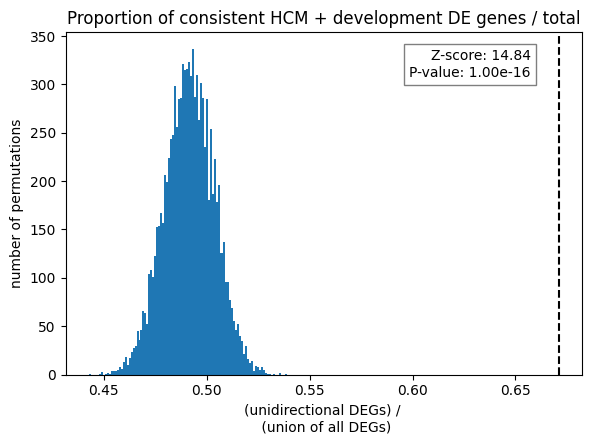

Up in both ICM and development: 205
Down in both ICM and development: 167
Up in both ICM and development: 205
Down in both ICM and development: 167
Up in ICM, down in development: 118
Down in ICM, up in development: 89
Ratio of consistent change: 0.6424870466321243
Mean (μ): 0.4973747709143332
Standard Deviation (σ): 0.020710570881716274
Observed ratio of consistent change between the two contrasts (v): 0.6424870466321243
Z-score: 7.0066767616676024
P-value: 2.440492252731019e-12


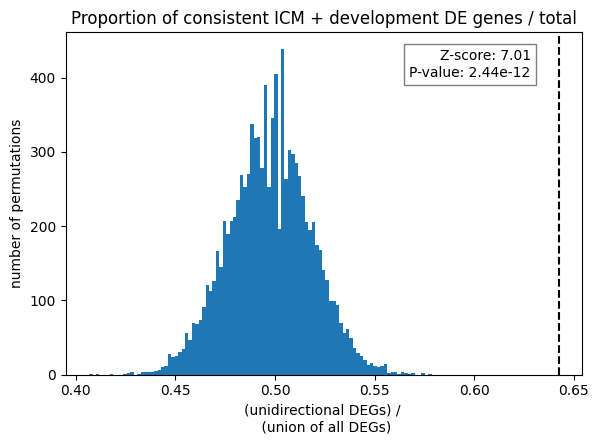

Up in both DCM and development: 324
Down in both DCM and development: 436
Up in both DCM and development: 324
Down in both DCM and development: 436
Up in DCM, down in development: 171
Down in DCM, up in development: 164
Ratio of consistent change: 0.6940639269406392
Mean (μ): 0.500390982532781
Standard Deviation (σ): 0.016203951273493458
Observed ratio of consistent change between the two contrasts (v): 0.6940639269406392
Z-score: 11.952204813443856
P-value: 0.0


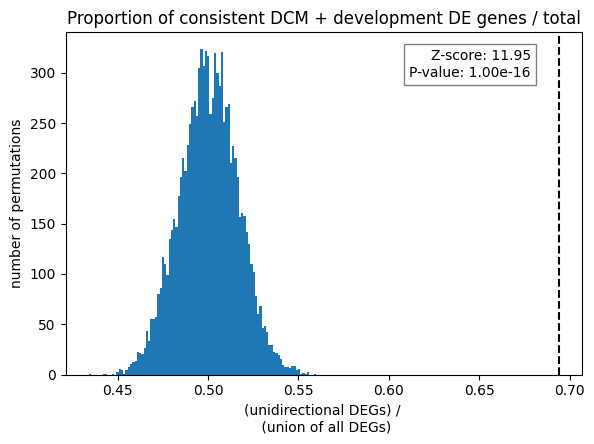

Contrast between HCM and development failed
Contrast between ICM and development failed
Contrast between DCM and development failed
Up in both HCM and development: 399
Down in both HCM and development: 338
Up in both HCM and development: 399
Down in both HCM and development: 338
Up in HCM, down in development: 108
Down in HCM, up in development: 100
Ratio of consistent change: 0.7798941798941799
Mean (μ): 0.49778928149308477
Standard Deviation (σ): 0.01871001740600612
Observed ratio of consistent change between the two contrasts (v): 0.7798941798941799
Z-score: 15.077746443492689
P-value: 0.0


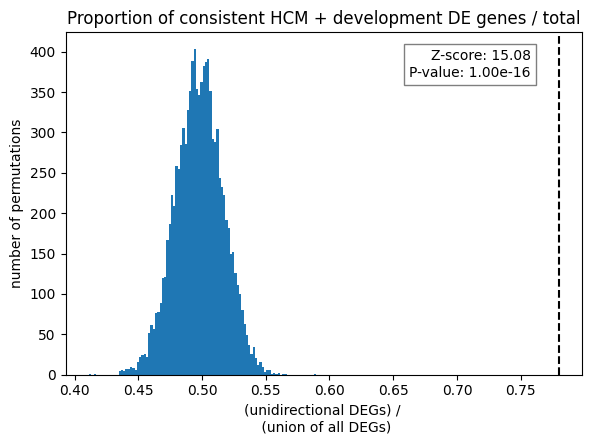

Up in both ICM and development: 412
Down in both ICM and development: 229
Up in both ICM and development: 412
Down in both ICM and development: 229
Up in ICM, down in development: 115
Down in ICM, up in development: 71
Ratio of consistent change: 0.7750906892382105
Mean (μ): 0.5157644737871888
Standard Deviation (σ): 0.0182400482985105
Observed ratio of consistent change between the two contrasts (v): 0.7750906892382105
Z-score: 14.21740837562357
P-value: 0.0


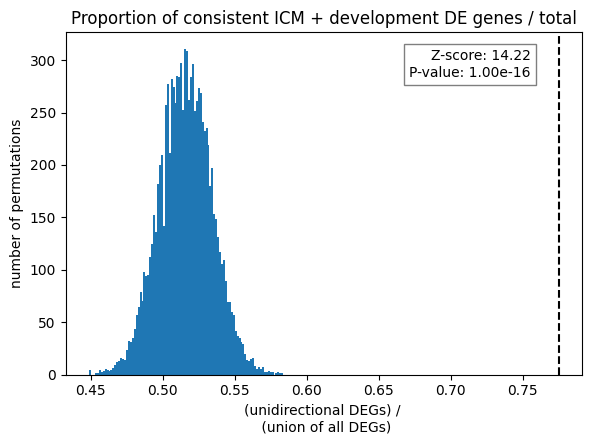

Up in both DCM and development: 230
Down in both DCM and development: 334
Up in both DCM and development: 230
Down in both DCM and development: 334
Up in DCM, down in development: 53
Down in DCM, up in development: 184
Ratio of consistent change: 0.704119850187266
Mean (μ): 0.4793236327565167
Standard Deviation (σ): 0.019938681360705167
Observed ratio of consistent change between the two contrasts (v): 0.704119850187266
Z-score: 11.274377345423357
P-value: 0.0


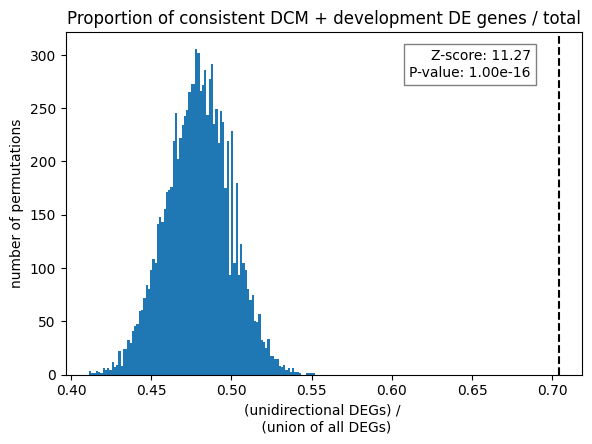

Contrast between HCM and development failed
Contrast between ICM and development failed
Contrast between DCM and development failed
Up in both HCM and development: 687
Down in both HCM and development: 677
Up in both HCM and development: 687
Down in both HCM and development: 677
Up in HCM, down in development: 434
Down in HCM, up in development: 171
Ratio of consistent change: 0.6927374301675978
Mean (μ): 0.49774633808043456
Standard Deviation (σ): 0.012370073223058572
Observed ratio of consistent change between the two contrasts (v): 0.6927374301675978
Z-score: 15.76313159761156
P-value: 0.0


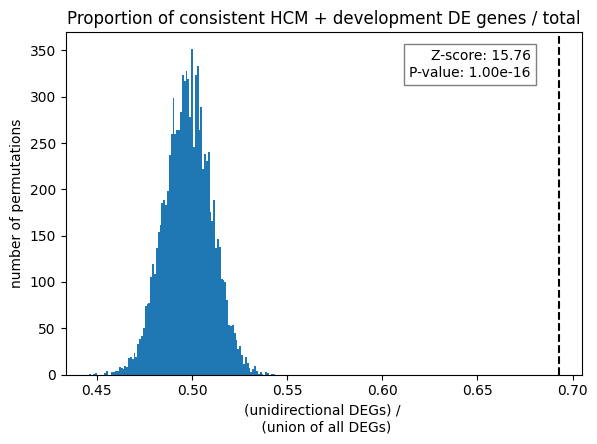

Up in both ICM and development: 420
Down in both ICM and development: 371
Up in both ICM and development: 420
Down in both ICM and development: 371
Up in ICM, down in development: 190
Down in ICM, up in development: 107
Ratio of consistent change: 0.7270220588235294
Mean (μ): 0.49751945327458325
Standard Deviation (σ): 0.015486566605527158
Observed ratio of consistent change between the two contrasts (v): 0.7270220588235294
Z-score: 14.819463306155715
P-value: 0.0


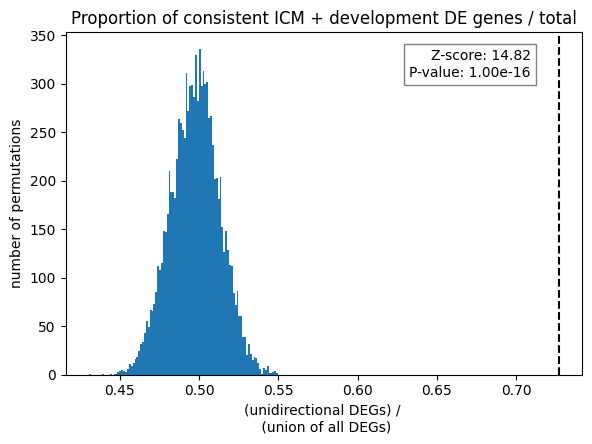

Up in both DCM and development: 603
Down in both DCM and development: 723
Up in both DCM and development: 603
Down in both DCM and development: 723
Up in DCM, down in development: 236
Down in DCM, up in development: 287
Ratio of consistent change: 0.7171444023796647
Mean (μ): 0.5030403509684046
Standard Deviation (σ): 0.012799430518349213
Observed ratio of consistent change between the two contrasts (v): 0.7171444023796647
Z-score: 16.727623241074777
P-value: 0.0


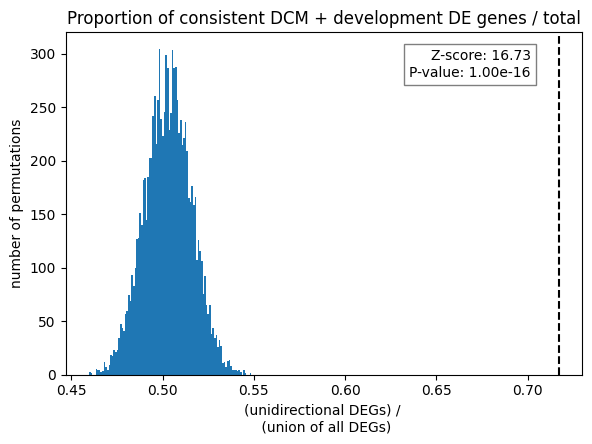

Up in both HCM and development: 13
Down in both HCM and development: 4
Up in both HCM and development: 13
Down in both HCM and development: 4
Up in HCM, down in development: 2
Down in HCM, up in development: 1
Ratio of consistent change: 0.85
Mean (μ): 0.37599064532689536
Standard Deviation (σ): 0.19643779574457768
Observed ratio of consistent change between the two contrasts (v): 0.85
Z-score: 2.4130252168449555
P-value: 0.015820724952056775


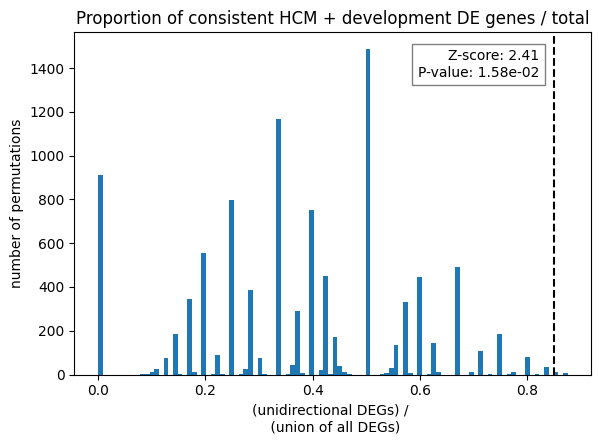

Up in both ICM and development: 0
Down in both ICM and development: 0
Up in both ICM and development: 0
Down in both ICM and development: 0
Up in ICM, down in development: 0
Down in ICM, up in development: 0
Ratio of consistent change: 0
Mean (μ): 0.0321
Standard Deviation (σ): 0.12272997007885057
Observed ratio of consistent change between the two contrasts (v): 0
Z-score: -0.2615498071039751
P-value: 0.7936685452487926


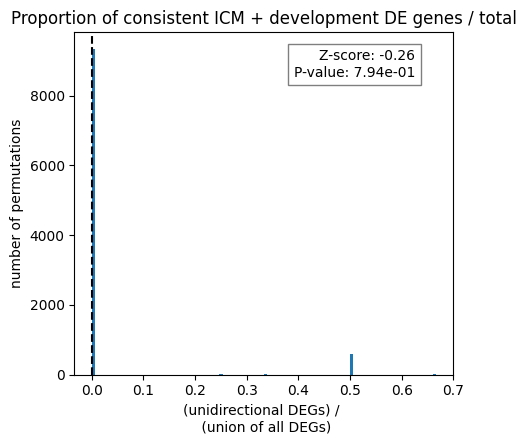

Up in both DCM and development: 14
Down in both DCM and development: 15
Up in both DCM and development: 14
Down in both DCM and development: 15
Up in DCM, down in development: 0
Down in DCM, up in development: 1
Ratio of consistent change: 0.9666666666666667
Mean (μ): 0.382196350638096
Standard Deviation (σ): 0.1634509446205442
Observed ratio of consistent change between the two contrasts (v): 0.9666666666666667
Z-score: 3.5758148561663834
P-value: 0.0003491386874425739


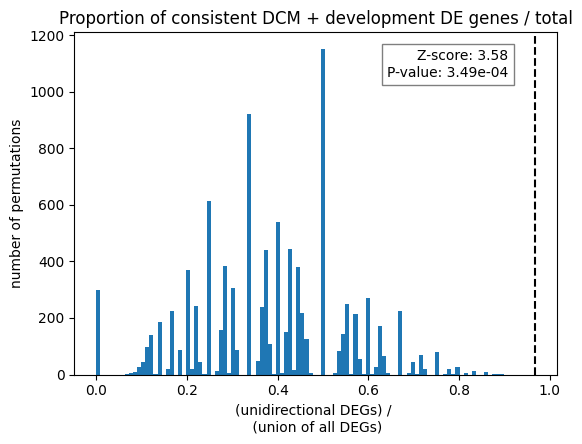

Up in both HCM and development: 59
Down in both HCM and development: 29
Up in both HCM and development: 59
Down in both HCM and development: 29
Up in HCM, down in development: 1
Down in HCM, up in development: 11
Ratio of consistent change: 0.88
Mean (μ): 0.46197353906403066
Standard Deviation (σ): 0.06899759737361266
Observed ratio of consistent change between the two contrasts (v): 0.88
Z-score: 6.0585654696411035
P-value: 1.3734084980399075e-09


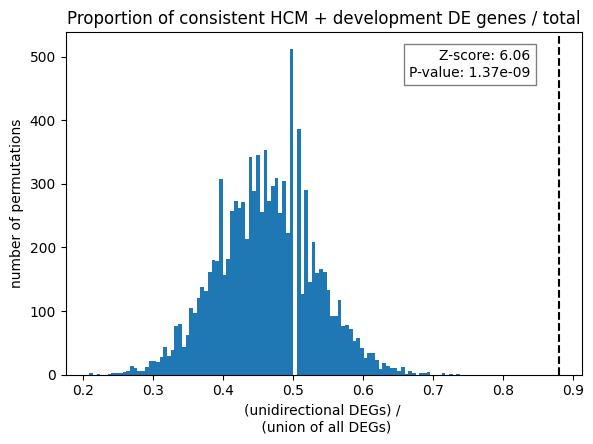

Up in both ICM and development: 1
Down in both ICM and development: 2
Up in both ICM and development: 1
Down in both ICM and development: 2
Up in ICM, down in development: 0
Down in ICM, up in development: 2
Ratio of consistent change: 0.6
Mean (μ): 0.33005648268398263
Standard Deviation (σ): 0.23246220916452862
Observed ratio of consistent change between the two contrasts (v): 0.6
Z-score: 1.1612361350526474
P-value: 0.2455458834340174


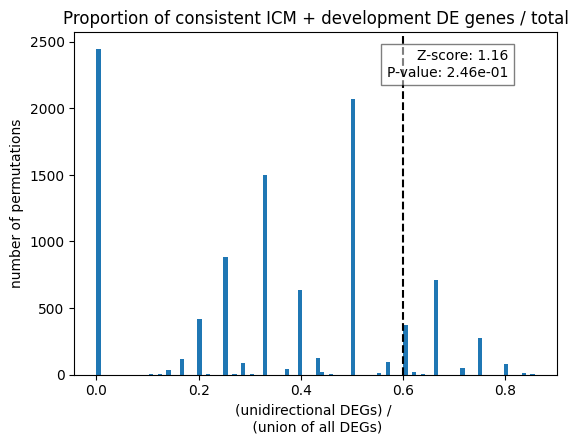

Up in both DCM and development: 10
Down in both DCM and development: 14
Up in both DCM and development: 10
Down in both DCM and development: 14
Up in DCM, down in development: 1
Down in DCM, up in development: 7
Ratio of consistent change: 0.75
Mean (μ): 0.46594686103107763
Standard Deviation (σ): 0.0893579095723284
Observed ratio of consistent change between the two contrasts (v): 0.75
Z-score: 3.1788247993760756
P-value: 0.0014787344182869422


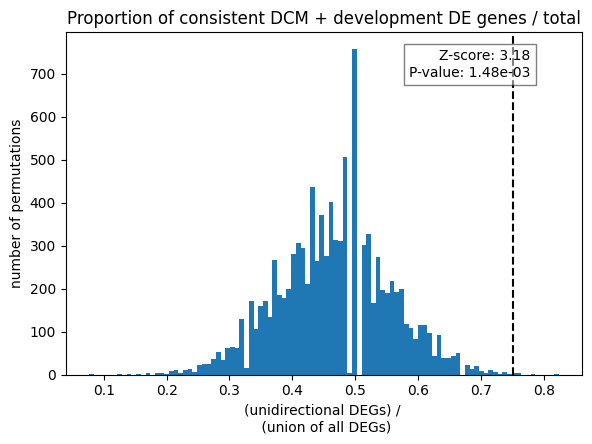

Up in both HCM and development: 138
Down in both HCM and development: 216
Up in both HCM and development: 138
Down in both HCM and development: 216
Up in HCM, down in development: 15
Down in HCM, up in development: 63
Ratio of consistent change: 0.8194444444444444
Mean (μ): 0.49603368733992836
Standard Deviation (σ): 0.03243884428244716
Observed ratio of consistent change between the two contrasts (v): 0.8194444444444444
Z-score: 9.969860648812185
P-value: 0.0


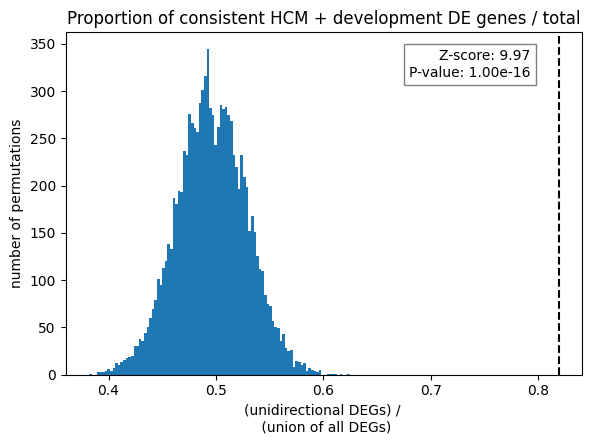

Up in both ICM and development: 53
Down in both ICM and development: 82
Up in both ICM and development: 53
Down in both ICM and development: 82
Up in ICM, down in development: 20
Down in ICM, up in development: 11
Ratio of consistent change: 0.8132530120481928
Mean (μ): 0.49584196456190893
Standard Deviation (σ): 0.04470116154154176
Observed ratio of consistent change between the two contrasts (v): 0.8132530120481928
Z-score: 7.100733773803772
P-value: 1.241007296926e-12


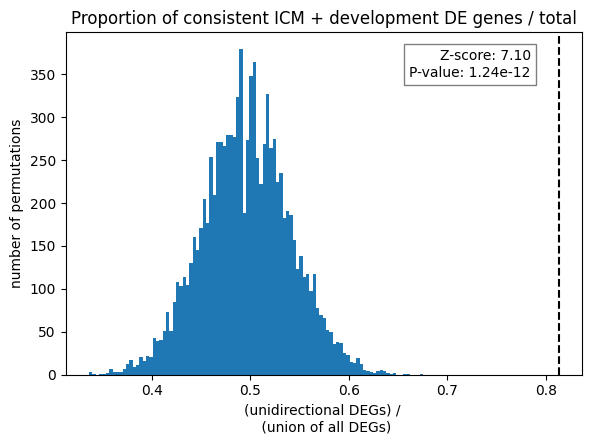

Up in both DCM and development: 148
Down in both DCM and development: 200
Up in both DCM and development: 148
Down in both DCM and development: 200
Up in DCM, down in development: 14
Down in DCM, up in development: 97
Ratio of consistent change: 0.7581699346405228
Mean (μ): 0.49786939901847144
Standard Deviation (σ): 0.029328581868617976
Observed ratio of consistent change between the two contrasts (v): 0.7581699346405228
Z-score: 8.875319536011283
P-value: 0.0


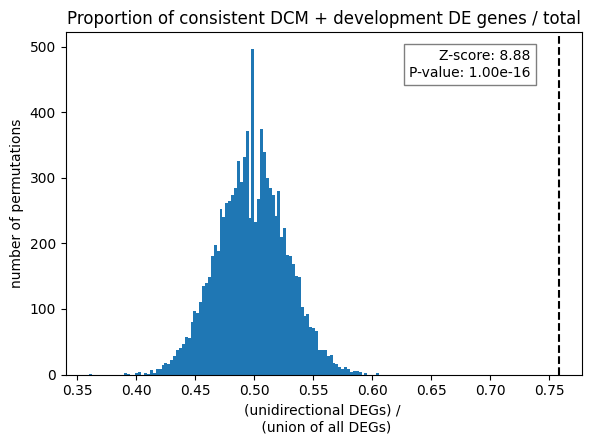

Up in both HCM and development: 70
Down in both HCM and development: 71
Up in both HCM and development: 70
Down in both HCM and development: 71
Up in HCM, down in development: 29
Down in HCM, up in development: 8
Ratio of consistent change: 0.7921348314606742
Mean (μ): 0.5036012949395514
Standard Deviation (σ): 0.03395651020326517
Observed ratio of consistent change between the two contrasts (v): 0.7921348314606742
Z-score: 8.497149288721022
P-value: 0.0


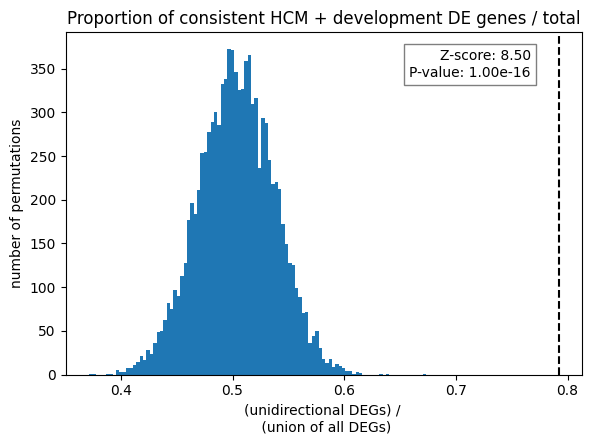

Up in both ICM and development: 2
Down in both ICM and development: 1
Up in both ICM and development: 2
Down in both ICM and development: 1
Up in ICM, down in development: 1
Down in ICM, up in development: 0
Ratio of consistent change: 0.75
Mean (μ): 0.2727421428571429
Standard Deviation (σ): 0.24079178462669254
Observed ratio of consistent change between the two contrasts (v): 0.75
Z-score: 1.9820354663792443
P-value: 0.047475271320984946


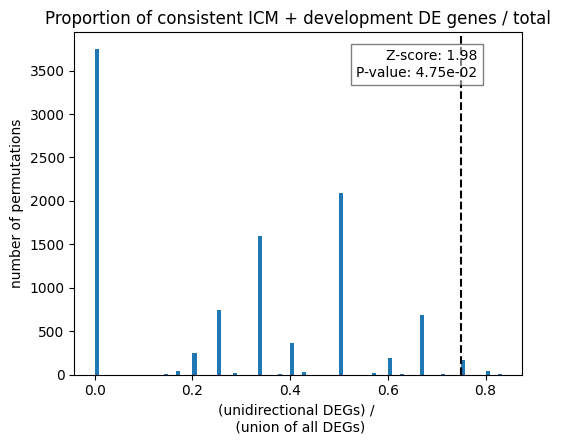

Up in both DCM and development: 109
Down in both DCM and development: 264
Up in both DCM and development: 109
Down in both DCM and development: 264
Up in DCM, down in development: 17
Down in DCM, up in development: 27
Ratio of consistent change: 0.894484412470024
Mean (μ): 0.47409062040881406
Standard Deviation (σ): 0.02799927444931668
Observed ratio of consistent change between the two contrasts (v): 0.894484412470024
Z-score: 15.014453064567522
P-value: 0.0


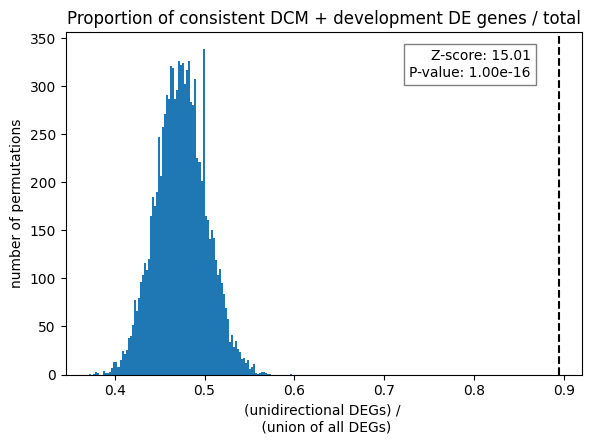

Up in both HCM and development: 209
Down in both HCM and development: 183
Up in both HCM and development: 209
Down in both HCM and development: 183
Up in HCM, down in development: 129
Down in HCM, up in development: 88
Ratio of consistent change: 0.6436781609195402
Mean (μ): 0.49723282171061245
Standard Deviation (σ): 0.02338557384297381
Observed ratio of consistent change between the two contrasts (v): 0.6436781609195402
Z-score: 6.2622084962403965
P-value: 3.795630476588485e-10


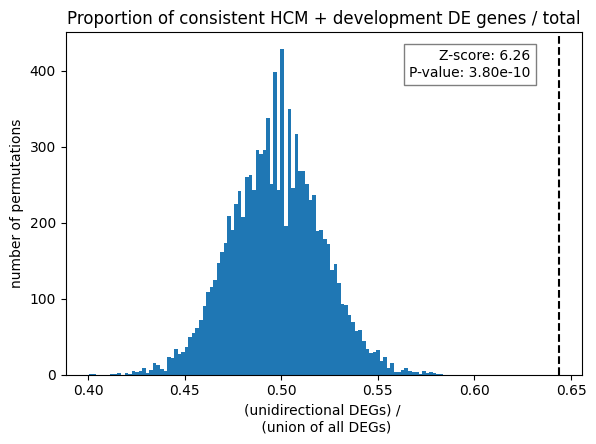

Up in both ICM and development: 100
Down in both ICM and development: 129
Up in both ICM and development: 100
Down in both ICM and development: 129
Up in ICM, down in development: 58
Down in ICM, up in development: 26
Ratio of consistent change: 0.731629392971246
Mean (μ): 0.4969111073710763
Standard Deviation (σ): 0.029032787043301703
Observed ratio of consistent change between the two contrasts (v): 0.731629392971246
Z-score: 8.084593644078778
P-value: 6.661338147750939e-16


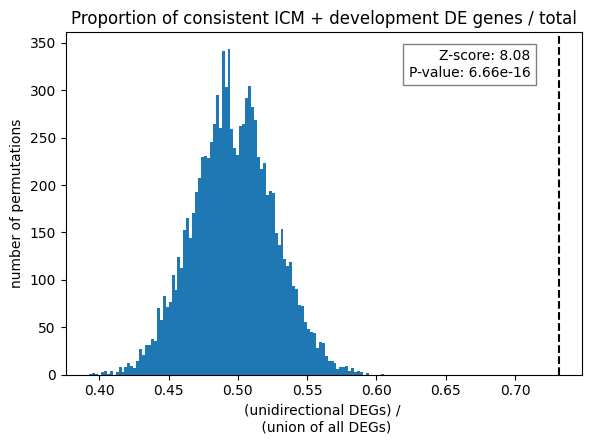

Up in both DCM and development: 184
Down in both DCM and development: 207
Up in both DCM and development: 184
Down in both DCM and development: 207
Up in DCM, down in development: 84
Down in DCM, up in development: 182
Ratio of consistent change: 0.5951293759512938
Mean (μ): 0.491637691179063
Standard Deviation (σ): 0.02223675308993474
Observed ratio of consistent change between the two contrasts (v): 0.5951293759512938
Z-score: 4.6540825611395285
P-value: 3.254263992502615e-06


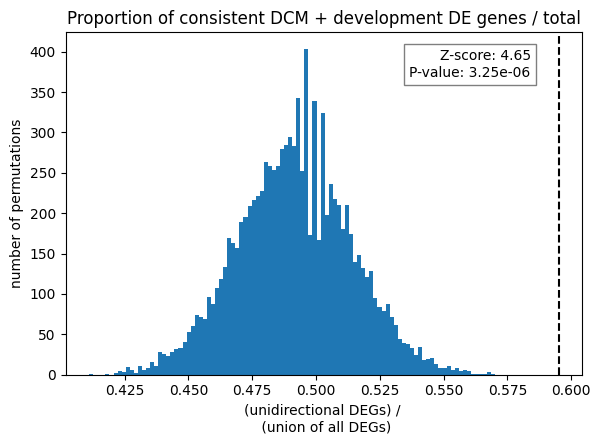

Contrast between HCM and development failed
Contrast between ICM and development failed
Contrast between DCM and development failed


In [23]:
# iterate through all cell types

results_list = []  # store results here

for cell_type in cell_types:

    for contrast1, contrast2 in contrast_pairs:
        
        # load DEGs
        try: 
            contrast1_df = load_DEG_df(contrast=contrast1, cell_type=cell_type)
            contrast2_df = load_DEG_df(contrast=contrast2, cell_type=cell_type)
        
            # analyze overlaps
            up_both, down_both, up_1_down_2, down_1_up_2, consistent_ratio = analyze_gene_contrasts(
                contrast1_df=contrast1_df,
                contrast2_df=contrast2_df,
                plots_dir=plots_dir,
                cell_type=cell_type,
                contrast1=contrast1,
                contrast2=contrast2
            )
        
            # save overlap info
            overlap_data = {
                "cell_type": cell_type,
                "contrast1": contrast1,
                "contrast2": contrast2,
                "up_both": up_both,
                "down_both": down_both,
                "up_1_down_2": up_1_down_2,
                "down_1_up_2": down_1_up_2,
                "consistent_ratio": consistent_ratio
            }
        
            # run simulation for z-score
            z_score, p_value, z_score_plot = run_simulations(
                gene_list=list(contrast1_df.index),
                sig_df_1=contrast1_df,
                sig_df_2=contrast2_df,
                obs_ratio_of_consistent_change=consistent_ratio,
                contrast_1=contrast1,
                contrast_2=contrast2,
                num_simulations=10000,
                pseudocount=1
            )
        
            # add simulation results
            overlap_data.update({
                "z_score": z_score,
                "p_value": p_value,
                "z_score_plot": z_score_plot  # keep the plot object
            })
        
            # append to results list
            results_list.append(overlap_data)
        except:
             print(f"Contrast between {contrast1} and {contrast2} failed")

In [24]:
results_df = pd.DataFrame([{k: v for k, v in d.items() if k != "z_score_plot"} for d in results_list])

In [25]:
results_df

,cell_type,contrast1,contrast2,up_both,down_both,up_1_down_2,down_1_up_2,consistent_ratio,z_score,p_value
0,Cardiomyocyte,HCM,development,733,489,436,163,0.671060,14.841260,1.000000e-16
1,Cardiomyocyte,ICM,development,205,167,118,89,0.642487,7.006677,2.440492e-12
2,Cardiomyocyte,DCM,development,324,436,171,164,0.694064,11.952205,1.000000e-16
3,Endothelial,HCM,development,399,338,108,100,0.779894,15.077746,1.000000e-16
4,Endothelial,ICM,development,412,229,115,71,0.775091,14.217408,1.000000e-16
5,Endothelial,DCM,development,230,334,53,184,0.704120,11.274377,1.000000e-16
6,Fibroblast,HCM,development,687,677,434,171,0.692737,15.763132,1.000000e-16
7,Fibroblast,ICM,development,420,371,190,107,0.727022,14.819463,1.000000e-16
8,Fibroblast,DCM,development,603,723,236,287,0.717144,16.727623,1.000000e-16
9,LEC,HCM,development,13,4,2,1,0.850000,2.413025,1.582072e-02


In [26]:
results_df.to_csv("04A_intersect_analysis_results.csv")